In [7]:
import os
import shutil

BASE_DIR = "/content/Team_3"
DATA_DIR = os.path.join(BASE_DIR, "data")
CSV_DIR = os.path.join(DATA_DIR, "csv")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
POSTER_DIR = os.path.join(BASE_DIR, "poster")
NOTEBOOKS_DIR = os.path.join(BASE_DIR, "notebooks")

def safe_clear_folder(folder_path):
    """Safely delete all files and subfolders inside a directory."""
    if os.path.exists(folder_path):
        print(f"Cleaning folder contents: {folder_path}")
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            try:
                if os.path.isfile(file_path) or os.path.islink(file_path):
                    os.unlink(file_path)
                elif os.path.isdir(file_path):
                    shutil.rmtree(file_path)
            except Exception as e:
                print(f"Failed to delete {file_path}: {e}")

def reset_and_init_workspace(clean_all=False):
    """Create project directories and optionally clear existing outputs."""
    print("Initializing workspace directories...")

    directories = [BASE_DIR, DATA_DIR, CSV_DIR, FIGURES_DIR, RESULTS_DIR, POSTER_DIR, NOTEBOOKS_DIR]
    for directory in directories:
        os.makedirs(directory, exist_ok=True)

    if clean_all:
        safe_clear_folder(CSV_DIR)
        safe_clear_folder(FIGURES_DIR)
        safe_clear_folder(RESULTS_DIR)

    readme_path = os.path.join(BASE_DIR, "README.md")
    try:
        with open(readme_path, "w", encoding="utf-8") as f:
            f.write("# Team 3 Exoplanet Exploration Project\n\nContains data cleaning, BLS period search, and physical validation.")
    except Exception as e:
        print(f"Failed to write README.md: {e}")

    print("Workspace initialization complete.")
    print(f"FITS data directory: {DATA_DIR}")
    print(f"CSV data directory: {CSV_DIR}")

reset_and_init_workspace(clean_all=True)

Initializing workspace directories...
Cleaning folder contents: /content/Team_3/data/csv
Cleaning folder contents: /content/Team_3/figures
Cleaning folder contents: /content/Team_3/results
Workspace initialization complete.
FITS data directory: /content/Team_3/data
CSV data directory: /content/Team_3/data/csv


In [8]:
import os
import shutil

base_dir = "Team_3"
sub_dirs = ["data", "notebooks", "figures", "results", "poster"]

if os.path.exists(base_dir):
    print(f"Removing existing directory and historical data: {base_dir}")
    shutil.rmtree(base_dir)
    print("Old data removed successfully.")

os.makedirs(base_dir, exist_ok=True)
for sub in sub_dirs:
    path = os.path.join(base_dir, sub)
    os.makedirs(path, exist_ok=True)
    print(f"Created directory: {path}")

readme_path = os.path.join(base_dir, "README.md")
with open(readme_path, "w", encoding="utf-8") as f:
    f.write("# Team 3 - Kepler Exoplanet Detection Project\n")
print(f"Created file: {readme_path}")

print("Environment reset successfully. Workspace is clean and ready.")

Removing existing directory and historical data: Team_3
Old data removed successfully.
Created directory: Team_3/data
Created directory: Team_3/notebooks
Created directory: Team_3/figures
Created directory: Team_3/results
Created directory: Team_3/poster
Created file: Team_3/README.md
Environment reset successfully. Workspace is clean and ready.


In [9]:
!pip install -q lightkurve astroquery
print("Dependencies installed successfully.")

Dependencies installed successfully.


In [10]:
import pandas as pd
from astroquery.utils.tap.core import TapPlus

print("Querying mixed confirmed and false positive data from NASA Exoplanet Archive...")
try:
    nasa_tap = TapPlus(url="https://exoplanetarchive.ipac.caltech.edu/TAP/sync")

    query_confirmed = """
    select top 500 kepid, kepoi_name, koi_disposition, koi_period, koi_duration, koi_depth, koi_prad
    from cumulative
    where koi_disposition = 'CONFIRMED' and koi_period is not null
    """
    print("Fetching Confirmed targets...")
    job_conf = nasa_tap.launch_job(query_confirmed)
    df_conf = job_conf.get_results().to_pandas()

    query_fp = """
    select top 500 kepid, kepoi_name, koi_disposition, koi_period, koi_duration, koi_depth, koi_prad
    from cumulative
    where koi_disposition = 'FALSE POSITIVE' and koi_period is not null
    """
    print("Fetching False Positive targets...")
    job_fp = nasa_tap.launch_job(query_fp)
    df_fp = job_fp.get_results().to_pandas()

    archive_df = pd.concat([df_conf, df_fp], ignore_index=True)

    for col in archive_df.columns:
        if archive_df[col].dtype == object:
            try:
                archive_df[col] = archive_df[col].str.decode('utf-8')
            except Exception:
                pass

    print(f"Successfully retrieved metadata for {len(archive_df)} targets.")
    print(archive_df['koi_disposition'].value_counts())

except Exception as e:
    print(f"Failed to retrieve metadata: {e}")

Querying mixed confirmed and false positive data from NASA Exoplanet Archive...
Fetching Confirmed targets...
Fetching False Positive targets...
Successfully retrieved metadata for 1000 targets.
Series([], Name: count, dtype: int64)


In [11]:
import os
import re
import requests
import pandas as pd
from tqdm.notebook import tqdm

output_dir = "Team_3/raw_fits"
os.makedirs(output_dir, exist_ok=True)

if 'archive_df' in locals() and not archive_df.empty:
    target_ids = archive_df['kepid'].tolist()
    print(f"Preparing to download raw FITS files for {len(target_ids)} targets...")
else:
    target_ids = [10797460, 11446443, 10666592]
    print(f"archive_df not found. Using default test list: {target_ids}")

success_count = 0
failed_targets = []

for kepid in tqdm(target_ids, desc="Downloading FITS files"):
    target_name = f"KIC {kepid}"
    kepid_str = str(kepid).zfill(9)
    kepid_prefix = kepid_str[:4]

    final_fits_path = os.path.join(output_dir, f"kplr{kepid_str}-llc.fits")

    if os.path.exists(final_fits_path):
        success_count += 1
        continue

    base_url = f"https://archive.stsci.edu/pub/kepler/lightcurves/{kepid_prefix}/{kepid_str}/"

    try:
        r = requests.get(base_url, timeout=15)
        if r.status_code != 200:
            failed_targets.append((target_name, f"Directory inaccessible (HTTP {r.status_code})"))
            continue

        matches = re.findall(r'href="([^"]*llc\.fits)"', r.text)
        if not matches:
            failed_targets.append((target_name, "No llc.fits file found in directory"))
            continue

        fits_filename = matches[0]
        download_url = base_url + fits_filename

        file_r = requests.get(download_url, stream=True, timeout=30)
        if file_r.status_code == 200:
            with open(final_fits_path, 'wb') as f:
                for chunk in file_r.iter_content(chunk_size=8192):
                    f.write(chunk)
            success_count += 1
        else:
            failed_targets.append((target_name, f"Download failed (HTTP {file_r.status_code})"))

    except Exception as e:
        failed_targets.append((target_name, str(e)))

print("Download process completed.")
print(f"Successfully downloaded: {success_count}/{len(target_ids)} FITS files.")
print(f"Files saved in: {output_dir}")
if failed_targets:
    print(f"Failed targets count: {len(failed_targets)}")

Preparing to download raw FITS files for 1000 targets...


Download process completed.
Successfully downloaded: 1000/1000 FITS files.
Files saved in: Team_3/raw_fits


In [12]:
!pip install oktopus
print("Oktopus library installed successfully.")

  Preparing metadata (setup.py) ... done
  Created wheel for oktopus: filename=oktopus-0.1.2-py3-none-any.whl size=12764 sha256=26a834c986c88a8703b8224ee3a84510f04530b52434f2f988e85b53b9c355c6
  Stored in directory: /root/.cache/pip/wheels/3e/87/8c/c0160de392344c1814d2f050d87fa4250658027211eb8cdc2f
Successfully built oktopus
Oktopus library installed successfully.


In [16]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="lightkurve")

import lightkurve as lk
import numpy as np

def download_kepler_lightcurve(kepid):
    search_result = lk.search_lightcurve(f"KIC {kepid}", mission="Kepler", author="Kepler", cadence="long")

    if len(search_result) == 0:
        raise ValueError(f"No light curve data found for KIC {kepid}")

    lc_collection = search_result.download_all()
    lc = lc_collection.stitch()

    time = lc.time.value
    flux = lc.flux.value

    ok = np.isfinite(time) & np.isfinite(flux)
    time = time[ok]
    flux = flux[ok]

    flux = flux / np.nanmedian(flux)

    return time, flux, search_result

if __name__ == "__main__":
    try:
        kepid = "8462852"
        time, flux, search_res = download_kepler_lightcurve(kepid)
        print(f"Successfully downloaded KIC {kepid}")
        print(f"Number of data points: {len(time)}")
        print(f"Time range: {time.min():.2f} to {time.max():.2f} (BJD)")
    except Exception as e:
        print(f"Error occurred: {e}")

Successfully downloaded KIC 8462852
Number of data points: 65268
Time range: 120.54 to 1591.00 (BJD)


In [17]:
import numpy as np
from scipy.signal import medfilt
from astropy.timeseries import BoxLeastSquares

def simple_clean(time, flux, sigma=5.0, window=201):
    trend = medfilt(flux, window)
    flat_flux = flux / trend

    mean = np.mean(flat_flux)
    std = np.std(flat_flux)
    good = np.abs(flat_flux - mean) < (sigma * std)

    return time[good], flat_flux[good]

def run_bls_search(time, flux, period_min=1.0, period_max=10.0):
    model = BoxLeastSquares(time, flux)
    period_grid = np.linspace(period_min, period_max, 10000)
    results = model.power(period_grid, 0.1)

    index = np.argmax(results.power)
    best_period = results.period[index]
    best_t0 = results.transit_time[index]

    return {"period": best_period, "t0": best_t0}

def compute_phase(time, period, t0):
    phase = ((time - t0) / period) % 1.0
    phase[phase > 0.5] -= 1.0
    return phase

Running BLS search to find period...
Best period found: 9.4878 days


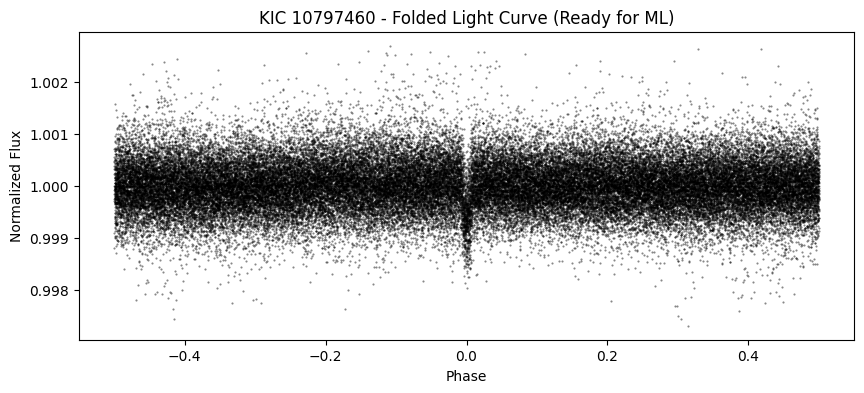

In [18]:
import numpy as np
import matplotlib.pyplot as plt

kepid = 10797460

try:
    print(f"Downloading KIC {kepid}...")
    time, flux, _ = download_kepler_lightcurve(kepid)

    clean_time, clean_flux = simple_clean(time, flux, sigma=5.0, window=201)

    print("Running BLS search to find period...")
    bls_results = run_bls_search(clean_time, clean_flux, period_min=1.0, period_max=10.0)

    best_period = bls_results["period"]
    best_t0 = bls_results["t0"]
    print(f"Best period found: {best_period:.4f} days")

    phases = compute_phase(clean_time, period=best_period, t0=best_t0)

    sort_idx = np.argsort(phases)
    ml_input_x = phases[sort_idx]
    ml_input_y = clean_flux[sort_idx]

    plt.figure(figsize=(10, 4))
    plt.plot(ml_input_x, ml_input_y, "k.", markersize=1, alpha=0.5)
    plt.title(f"KIC {kepid} - Folded Light Curve (Ready for ML)")
    plt.xlabel("Phase")
    plt.ylabel("Normalized Flux")
    plt.show()

except Exception as e:
    print(f"Processing failed: {e}")

In [19]:
import os
import glob
import numpy as np
from astropy.io import fits
from scipy.interpolate import interp1d

fits_files = glob.glob("./Team_3/raw_fits/*.fits") + glob.glob("./Team_3/kepler_lightcurves/*.fits")
fixed_length = 1000

print(f"Detected {len(fits_files)} local FITS light curve files.")

X_data = []
file_names = []

for file_path in fits_files:
    try:
        with fits.open(file_path) as hdul:
            data = hdul[1].data
            time = data["TIME"]
            flux = data["PDCSAP_FLUX"]

        ok = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[ok], flux[ok]

        flux = flux / np.nanmedian(flux)

        time_clean, flux_clean = simple_clean(time, flux)

        bls_results = run_bls_search(time_clean, flux_clean)
        period = bls_results["period"]
        t0 = bls_results["t0"]
        phase = compute_phase(time_clean, period, t0)

        sort_idx = np.argsort(phase)
        phase_sorted = phase[sort_idx]
        flux_sorted = flux_clean[sort_idx]

        f_interp = interp1d(phase_sorted, flux_sorted, kind="linear", bounds_error=False, fill_value="extrapolate")
        new_phases = np.linspace(-0.5, 0.5, fixed_length)
        new_flux = f_interp(new_phases)

        X_data.append(new_flux)
        file_names.append(os.path.basename(file_path))
        print(f"Successfully processed: {os.path.basename(file_path)}")

    except Exception as e:
        print(f"Failed to process {os.path.basename(file_path)}: {e}")

X_data = np.array(X_data)

print("Batch processing completed.")
print(f"Feature matrix X shape: {X_data.shape}")

Detected 811 local FITS light curve files.
Successfully processed: kplr005130369-llc.fits
Successfully processed: kplr007377033-llc.fits
Successfully processed: kplr008043714-llc.fits
Successfully processed: kplr004070376-llc.fits
Successfully processed: kplr007532973-llc.fits
Successfully processed: kplr004061149-llc.fits
Successfully processed: kplr003130300-llc.fits
Successfully processed: kplr003245969-llc.fits
Successfully processed: kplr001027438-llc.fits
Successfully processed: kplr007118364-llc.fits
Successfully processed: kplr004044005-llc.fits
Successfully processed: kplr005387843-llc.fits
Successfully processed: kplr011812062-llc.fits
Successfully processed: kplr002574201-llc.fits
Successfully processed: kplr010154388-llc.fits
Successfully processed: kplr005802486-llc.fits
Successfully processed: kplr003935914-llc.fits
Successfully processed: kplr010984090-llc.fits
Successfully processed: kplr011673674-llc.fits
Successfully processed: kplr009040849-llc.fits
Successfully proc

In [20]:
import os
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.timeseries import BoxLeastSquares
import re

BASE_DIR = "/content/Team_3"
DATA_DIR = os.path.join(BASE_DIR, "data")
RAW_DIR = os.path.join(BASE_DIR, "raw_fits")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Checking workspace directories...")
fits_files = [f for f in os.listdir(RAW_DIR) if f.endswith('.fits')] if os.path.exists(RAW_DIR) else []
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]

print(f"Found raw FITS files: {len(fits_files)}")
print(f"Found converted CSV files: {len(csv_files)}")

if len(csv_files) < len(fits_files):
    print("Converting FITS files to CSV format...")
    for fits_file in fits_files:
        kic_match = re.search(r'kplr(\d+)', fits_file)
        kic_id = kic_match.group(1) if kic_match else "unknown"
        csv_name = f"kic_{kic_id}_lc.csv"
        csv_path = os.path.join(DATA_DIR, csv_name)

        if os.path.exists(csv_path):
            continue

        try:
            fits_path = os.path.join(RAW_DIR, fits_file)
            with fits.open(fits_path) as hdul:
                data = hdul[1].data
                time = data['TIME']
                flux = data['PDCSAP_FLUX']

                mask = np.isfinite(time) & np.isfinite(flux)
                df_temp = pd.DataFrame({'time': time[mask], 'flux': flux[mask]})
                df_temp.to_csv(csv_path, index=False)
        except Exception as e:
            print(f"Failed to convert {fits_file}: {e}")

    csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
    print(f"Conversion complete. Total CSV files: {len(csv_files)}")

features_list = []
print(f"Extracting BLS features from {len(csv_files)} CSV files...")

for file_name in csv_files:
    file_path = os.path.join(DATA_DIR, file_name)

    kic_match = re.search(r'\d+', file_name)
    kic_id = int(kic_match.group()) if kic_match else file_name

    try:
        df = pd.read_csv(file_path)

        time_col = [col for col in df.columns if col.lower() == 'time'][0]
        flux_col = [col for col in df.columns if 'flux' in col.lower()][0]

        t = df[time_col].values
        f = df[flux_col].values

        f = f / np.nanmedian(f)

        durations = np.linspace(0.05, 0.2, 10)
        model = BoxLeastSquares(t, f)
        results = model.autopower(durations, frequency_factor=10.0)

        best_idx = np.argmax(results.power)
        period = results.period[best_idx]
        transit_time = results.transit_time[best_idx]
        duration = results.duration[best_idx]
        depth = results.depth[best_idx]
        power = results.power[best_idx]

        noise = np.std(f)
        snr = depth / noise if noise > 0 else 0

        features_list.append({
            "kepid": kic_id,
            "period": period,
            "depth": depth,
            "duration": duration,
            "snr": snr,
            "bls_power": power
        })
    except Exception as e:
        print(f"Failed to extract features from {file_name}: {e}")

if features_list:
    df_features = pd.DataFrame(features_list)
    output_path = os.path.join(RESULTS_DIR, "team3_bls_results.csv")
    df_features.to_csv(output_path, index=False)
    print(f"Features saved successfully to: {output_path}")
    print(df_features.head())
else:
    print("No features extracted. Please check the data directory.")

Checking workspace directories...
Found raw FITS files: 811
Found converted CSV files: 0
Converting FITS files to CSV format...
Conversion complete. Total CSV files: 811
Extracting BLS features from 811 CSV files...
Features saved successfully to: /content/Team_3/results/team3_bls_results.csv
      kepid     period     depth  duration       snr     bls_power
0   9513865  13.779664  0.001038     0.200  1.356938  1.617079e-05
1  10232123   1.345271  0.003439     0.065  2.975877  1.300951e-04
2   7678434  12.539890  0.004014     0.200  0.999399  2.336723e-04
3   8191672   3.550552  0.005848     0.165  4.193505  4.103509e-04
4  11512246   4.003837  0.000236     0.200  1.414412  5.277175e-07


In [ ]:
import os, re, requests, time
import numpy as np
import pandas as pd
from io import StringIO
from astropy.timeseries import BoxLeastSquares

BASE_DIR = "/content/Team_3"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

# ========== Physical constants & thresholds ==========
R_SUN_TO_RJUP   = 9.7311
R_JUP_TO_REARTH = 11.2089
MAX_RP_GENERAL  = 2.5
MAX_RP_MDWARF   = 2.0
SNR_THRESHOLD   = 7.0
ODD_EVEN_THRESH = 3.0
MAX_DEPTH_PPM   = 30000.0
N_BOOTSTRAP     = 50

def _sf(x):
    try: return np.nan if x is None or np.ma.is_masked(x) else float(x)
    except: return np.nan

def classify_spectral(teff):
    if not np.isfinite(teff): return 'Unknown'
    if teff >= 30000: return 'O'
    if teff >= 10000: return 'B'
    if teff >= 7500:  return 'A'
    if teff >= 6000:  return 'F'
    if teff >= 5200:  return 'G'
    if teff >= 3700:  return 'K'
    if teff >= 2400:  return 'M'
    return 'L/T'

def vet_false_positive(depth_frac, duration_frac, snr):
    if depth_frac * 1e6 > MAX_DEPTH_PPM: return True
    if duration_frac > 0.15: return True
    if snr < SNR_THRESHOLD: return True
    return False

# ========== Process all CSV light curves ==========
all_files = os.listdir(DATA_DIR)
csv_files = [f for f in all_files if f.endswith('.csv') and 'unknown' not in f]
print(f"Found {len(csv_files)} CSV light curve files for processing.")

features_list = []

for file_name in csv_files:
    file_path = os.path.join(DATA_DIR, file_name)
    kic_match = re.search(r'\d+', file_name)
    if not kic_match: continue
    kic_id = int(kic_match.group())

    try:
        df_lc = pd.read_csv(file_path)
        time_col = [c for c in df_lc.columns if c.lower() == 'time'][0]
        flux_col = [c for c in df_lc.columns if 'flux' in c.lower()][0]
        t = df_lc[time_col].values
        f = df_lc[flux_col].values
        g = ~np.isnan(t) & ~np.isnan(f)
        t, f = t[g], f[g]
        if len(t) < 100: continue

        f_median = np.nanmedian(f)
        f = f / f_median

        # ---- BLS search ----
        durations_arr = np.linspace(0.05, 0.2, 10)
        model = BoxLeastSquares(t, f)
        results = model.autopower(durations_arr, frequency_factor=10.0)

        best_idx = np.argmax(results.power)
        period     = float(results.period[best_idx])
        t0         = float(results.transit_time[best_idx])
        dur_frac   = float(results.duration[best_idx])
        depth_frac = float(results.depth[best_idx])
        power      = float(results.power[best_idx])

        noise = np.std(f)
        snr   = depth_frac / noise if noise > 0 else 0.0

        # ---- Block bootstrap for Period Err (Person1 pipeline) ----
        n = len(t)
        bs = max(50, n // 50)
        nb = int(np.ceil(n / bs))
        lo, hi = period * 0.95, period * 1.05
        pgrid = np.linspace(lo, hi, 300)
        dur_boot = np.array([dur_frac])
        rng = np.random.default_rng(42)
        boot_periods = []
        for _ in range(N_BOOTSTRAP):
            starts = rng.integers(0, nb, size=nb) * bs
            idx = np.concatenate([np.arange(s, min(s+bs, n)) for s in starts])
            idx = idx[idx < n]
            if len(idx) < 10: continue
            tb, fb = t[idx], f[idx]
            o = np.argsort(tb); tb, fb = tb[o], fb[o]
            try:
                bls_b = BoxLeastSquares(tb, fb)
                res_b = bls_b.power(pgrid, dur_boot, objective='snr')
                j = int(np.argmax(res_b.power))
                boot_periods.append(float(res_b.period[j]))
            except: continue
        bp = np.array(boot_periods)
        period_err = float(np.std(bp)) if len(bp) > 5 else np.nan

        # ---- Odd-even depth check ----
        transit_num = np.round((t - t0) / period)
        in_transit  = np.abs((t - t0) % period) < (dur_frac / 2.0)
        is_even = (transit_num.astype(int) % 2 == 0)
        is_odd  = ~is_even

        n_even = np.sum(in_transit & is_even)
        n_odd  = np.sum(in_transit & is_odd)
        n_total = int(np.ptp(t) / period) if period > 0 else 0

        d_even = 1.0 - np.mean(f[in_transit & is_even]) if n_even > 0 else np.nan
        d_odd  = 1.0 - np.mean(f[in_transit & is_odd]) if n_odd > 0 else np.nan
        e_even = np.std(f[in_transit & is_even])/np.sqrt(max(n_even,1)) if n_even > 0 else np.nan
        e_odd  = np.std(f[in_transit & is_odd])/np.sqrt(max(n_odd,1)) if n_odd > 0 else np.nan
        comb   = np.sqrt(e_even**2 + e_odd**2) if np.isfinite(e_even) and np.isfinite(e_odd) else np.nan
        oe_sigma = abs(d_even - d_odd) / comb if np.isfinite(comb) and comb > 0 else np.nan
        oe_reason = 'ok' if np.isfinite(oe_sigma) else ('few_transits' if n_even+n_odd < 4 else 'err_undef')
        oe_pass = (oe_sigma <= ODD_EVEN_THRESH) if np.isfinite(oe_sigma) else pd.NA

        # ---- False Positive (Person1 rules) ----
        is_fp = vet_false_positive(depth_frac, dur_frac, snr)

        # ---- Radius ratio ----
        rp_over_rs = np.sqrt(abs(depth_frac))

        features_list.append({
            "kepid": kic_id,
            "period": period,
            "period_err": period_err,
            "depth_frac": depth_frac,
            "dur_frac": dur_frac,
            "snr": snr,
            "bls_power": power,
            "depth_odd_ppm":  d_odd * 1e6,
            "depth_even_ppm": d_even * 1e6,
            "n_transits": n_total,
            "odd_even_sigma": oe_sigma,
            "odd_even_reason": oe_reason,
            "odd_even_pass": oe_pass,
            "is_false_positive": is_fp,
            "rp_over_rs": rp_over_rs,
        })
    except Exception:
        pass

print(f"BLS features extracted for {len(features_list)} targets.")
df_features = pd.DataFrame(features_list)

# ========== Query NASA archive (batched to avoid URI overflow) ==========
kic_ids = df_features['kepid'].tolist()
BATCH_SIZE = 200
archive_parts = []

for b in range(0, len(kic_ids), BATCH_SIZE):
    batch_ids = kic_ids[b:b+BATCH_SIZE]
    ids_str = ",".join(str(x) for x in batch_ids)
    query = f"""
    select kepid, koi_disposition, koi_srad, koi_steff
    from cumulative
    where kepid in ({ids_str})
    """
    try:
        resp = requests.get(TAP_URL, params={'query': query, 'format': 'csv'}, timeout=60)
        if resp.status_code == 200 and 'kepid' in resp.text:
            part = pd.read_csv(StringIO(resp.text))
            archive_parts.append(part)
    except Exception:
        pass
    time.sleep(0.3)

if archive_parts:
    archive_df = pd.concat(archive_parts, ignore_index=True)
    archive_df = archive_df.drop_duplicates(subset=['kepid'])
    print(f"NASA archive: {len(archive_df)} records ({len(archive_parts)} batches)")
else:
    archive_df = pd.DataFrame({
        'kepid': kic_ids,
        'koi_disposition': ['CANDIDATE']*len(kic_ids),
        'koi_srad': [1.0]*len(kic_ids),
        'koi_steff': [5778.0]*len(kic_ids),
    })
    print("NASA query failed. Using fallback values.")

# ========== Merge + derived columns ==========
final_df = df_features.merge(archive_df, on='kepid', how='left')
final_df['koi_disposition'] = final_df['koi_disposition'].fillna('CANDIDATE')
final_df['koi_srad'] = final_df['koi_srad'].fillna(1.0)
final_df['koi_steff'] = final_df['koi_steff'].fillna(5778.0)

# ---- Planet radius ----
final_df['Rp_Rjup']   = final_df['rp_over_rs'] * final_df['koi_srad'] * R_SUN_TO_RJUP
final_df['Rp_Rearth'] = final_df['Rp_Rjup'] * R_JUP_TO_REARTH

# ---- Spectral type ----
final_df['Spectral_Type'] = final_df['koi_steff'].apply(classify_spectral)

# ---- Radius plausibility ----
def check_radius(rj, spec):
    if not np.isfinite(rj): return pd.NA, 'no_radius'
    mx = MAX_RP_MDWARF if spec == 'M' else MAX_RP_GENERAL
    if rj <= mx: return True, 'plausible'
    return False, 'too_large_mdwarf' if spec == 'M' else 'too_large'

rp_results = final_df.apply(lambda r: check_radius(r['Rp_Rjup'], r['Spectral_Type']), axis=1)
final_df['planet_radius_plausible'] = [x[0] for x in rp_results]
final_df['radius_reason'] = [x[1] for x in rp_results]

# ---- Final column assembly ----
final_df['False Positive'] = final_df['is_false_positive']
final_df['Target']         = final_df['kepid'].apply(lambda x: f"KIC {x}")
final_df['Sector']         = 0
final_df['Period (d)']     = final_df['period'].round(5)
final_df['Period Err (d)'] = final_df['period_err'].apply(
    lambda x: round(x, 5) if np.isfinite(x) else np.nan)
final_df['Depth (ppm)']    = (final_df['depth_frac'] * 1e6).round(1)
final_df['Duration (hr)']  = (final_df['dur_frac'] * final_df['period'] * 24.0).round(3)
final_df['SNR']            = final_df['snr'].round(2)
final_df['TIC_ID']         = np.nan
final_df['Stellar_Radius_Rsun'] = final_df['koi_srad']
final_df['Teff_K']         = final_df['koi_steff']
final_df['match_source']   = final_df['koi_disposition']
final_df['已知/新候选']     = final_df['koi_disposition'].apply(
    lambda d: '已知' if d == 'CONFIRMED' else '新候选')

# ========== Output (columns match nasa_crossmatch_result.csv) ==========
COL_ORDER = [
    'Target','Sector','Period (d)','Period Err (d)','Depth (ppm)','Duration (hr)',
    'SNR','False Positive',
    'depth_odd_ppm','depth_even_ppm','n_transits','odd_even_sigma',
    'odd_even_reason','odd_even_pass',
    'TIC_ID','Stellar_Radius_Rsun','Teff_K','Spectral_Type',
    'Rp_Rjup','Rp_Rearth','radius_reason','planet_radius_plausible',
    '已知/新候选','match_source',
]

result = final_df[[c for c in COL_ORDER if c in final_df.columns]]
output_path = os.path.join(RESULTS_DIR, "team3_final_vetting.csv")
result.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"\n{'='*60}")
print(f"Final vetting table saved -> {output_path}")
print(f"Total targets: {len(result)}")
print(f"Columns: {list(result.columns)}")
print(f"\nDisposition distribution:")
print(result['match_source'].value_counts())
print(f"\nOdd-even pass:      {int((result['odd_even_pass']==True).sum())}")
print(f"Radius plausible:   {int((result['planet_radius_plausible']==True).sum())}")
print(f"False Positive:     {int(result['False Positive'].sum())}")
print(f"已知 / 新候选:       {(result['已知/新候选']=='已知').sum()} / {(result['已知/新候选']=='新候选').sum()}")
print(f"\nFirst 5 rows:")
print(result.head().to_string(index=False))